# DHS Data Cleaning and Target Engineering for HIV Care Gap AI

## Overview
This notebook implements the complete data cleaning pipeline for Demographic and Health Survey (DHS) individual-level data. The primary objectives are:

1. Load raw DHS individual features dataset
2. Decode categorical variables using DHS standard mappings
3. Impute missing values using appropriate strategies
4. Engineer the dropout target variable for HIV care gap prediction
5. Prepare model-ready dataset with one-hot encoding

## Data Source
- Raw file: `individual_features.csv` (DHS individual recode)
- Contains survey responses from individuals across Kenya's 47 counties
- Includes demographics, HIV testing history, and healthcare access indicators

## Output
- Cleaned dataset: `individual_features_clean.csv`
- Missing value heatmaps (before/after)
- Class ratio report for modeling team

In [20]:
# Cell 1: Setup and Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

ROOT_PATH = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT_PATH not in sys.path:
    sys.path.append(ROOT_PATH)

import constants as c
from src.dhs_cleaner import DHSCleaner

print("Setup complete")
print(f"Root path: {ROOT_PATH}")

Setup complete
Root path: /home/skylar_lorena/DS/Phase5/Phase-5-HIV-Care-Gap-AI


## Data Loading

We ingest the filtered DHS individual features dataset. The data contains individual survey responses with columns representing demographics, HIV testing status, and healthcare access indicators.

**Expected structure:**
- 32,156 rows (individual respondents)
- 50+ columns including county codes, age groups, education levels
- HIV testing history and health insurance status

In [21]:
# Cell 2: Initialize Cleaner and Load Data
cleaner = DHSCleaner(c)
df = cleaner.load_data(c.DHS_REDUCED)

print(f"Dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")

Loaded 32156 rows with 15 columns
Columns: ['case_id', 'county', 'age_group', 'education_level', 'wealth_index', 'worked_last_12months', 'ever_tested_hiv', 'tested_hiv_last_12months', 'distance_to_facility', 'marital_status', 'currently_in_union', 'num_sexual_partners', 'knows_aids_death', 'told_hiv_positive', 'has_health_insurance']
Dataset shape: 32,156 rows, 15 columns


## Baseline Data Assessment

Understanding the raw data structure is critical for appropriate cleaning. We examine:
- Column names to identify DHS standard codes
- Data types for each column
- First few rows to understand value patterns
- Missing value distribution

In [22]:
# Cell 3: Initial Data Inspection
print("Columns in dataset:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
df.head()

print("\nData types:")
print(df.dtypes.value_counts())

Columns in dataset:
['case_id', 'county', 'age_group', 'education_level', 'wealth_index', 'worked_last_12months', 'ever_tested_hiv', 'tested_hiv_last_12months', 'distance_to_facility', 'marital_status', 'currently_in_union', 'num_sexual_partners', 'knows_aids_death', 'told_hiv_positive', 'has_health_insurance']

First 5 rows:

Data types:
int64      7
float64    7
object     1
Name: count, dtype: int64


## Data Quality Assessment: Missing Values

Transparency regarding data gaps is critical for stakeholder trust. We visualize the missing value distribution in the raw data to justify our subsequent imputation strategies.

**Key observations before cleaning:**
- HIV-related variables often have significant missing values
- Some demographic variables may have missing codes
- Geographic variables should be complete for valid analysis

This heatmap serves as a baseline to measure our imputation success.

Heatmap saved to ../figures/dhs_missing_before.png


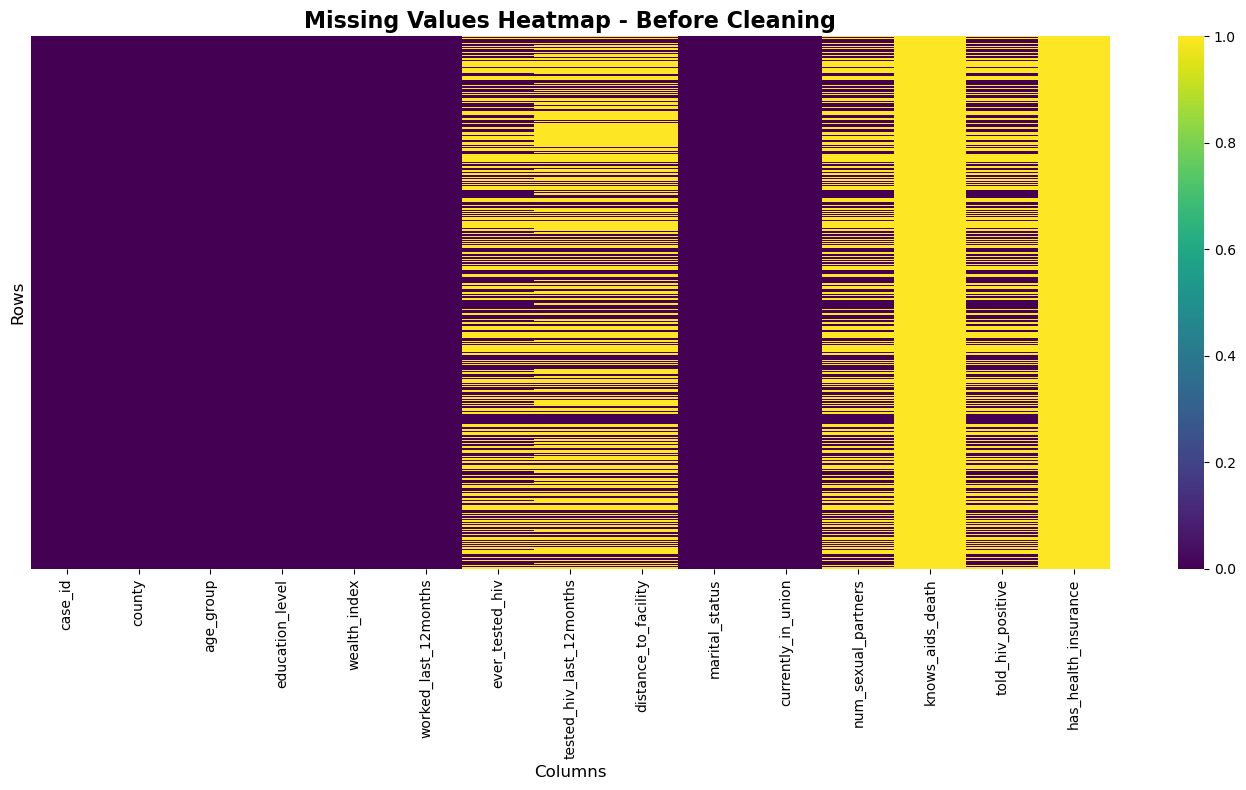


Columns with missing values (top 10):
knows_aids_death            100.000000
has_health_insurance        100.000000
tested_hiv_last_12months     57.037567
distance_to_facility         57.037567
num_sexual_partners          47.443712
ever_tested_hiv              47.440602
told_hiv_positive            47.440602
dtype: float64


In [23]:
# Cell 4: Missing Values Heatmap (Before)
os.makedirs("../figures", exist_ok=True)

plt.figure(figsize=(14, 8))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap="viridis")
plt.title("Missing Values Heatmap - Before Cleaning", fontsize=16, fontweight="bold")
plt.xlabel("Columns", fontsize=12)
plt.ylabel("Rows", fontsize=12)
plt.tight_layout()

before_path = "../figures/dhs_missing_before.png"
plt.savefig(before_path, dpi=300, bbox_inches="tight")
print(f"Heatmap saved to {before_path}")
plt.show()

missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

print("\nColumns with missing values (top 10):")
print(missing_pct.head(10))

## Feature Decoding: County Identifiers

DHS datasets typically store geographic identifiers as numeric codes (1-47 for Kenya's counties). To make the data interpretable for analysis and visualization, we map these codes to actual county names using the `DHS_COUNTY_MAP` from constants.

In [24]:
# Cell 5: Decode County Codes
county_col = None
for col in ["county", "hv024", "County", "COUNTY"]:
    if col in df.columns:
        county_col = col
        break

if county_col:
    cleaner.decode_county(county_col=county_col)
    sample_counties = cleaner.clean_df[["county_name"]].dropna().head(10)
    print("\nSample decoded counties:")
    print(sample_counties)
else:
    print("County column not found. Available columns:", df.columns[:20])

Decoded 47 counties

Sample decoded counties:
  county_name
0     Mombasa
1     Mombasa
2     Mombasa
3     Mombasa
4     Mombasa
5     Mombasa
6     Mombasa
7     Mombasa
8     Mombasa
9     Mombasa


### Demographic Variable Decoding

DHS uses standardized numeric codes for demographic characteristics. We decode these using the mapping dictionaries defined in constants:

| Original Code | Decoded Value | Mapping Source |
|--------------|---------------|----------------|
| Age groups (1-7) | 15-19, 20-24, ... | DHS_AGE_GROUP_MAP |
| Education (0-3) | No education, Primary, Secondary, Higher | DHS_EDUCATION_MAP |
| Wealth (1-5) | Poorest to Richest | DHS_WEALTH_MAP |
| Marital (0-5) | Never married, Married, etc. | DHS_MARITAL_MAP |

**Rationale:** Decoded variables improve model interpretability and enable stratified analyses by demographic segments.

In [25]:
# Cell 6: Decode All Demographics (includes work and union status)
cleaner.decode_demographics()

decode_cols = [
    "age_group",
    "education_level",
    "wealth_index",
    "marital_status",
    "worked_last_12months",
    "currently_in_union",
]
available_decode = [col for col in decode_cols if col in cleaner.clean_df.columns]

print("Decoded variables sample:")
cleaner.clean_df[available_decode].head()

Decoded age_group (numeric → labels)
  Sample: ['30-34' '35-39' '25-29']
Decoded marital_status (numeric → labels)
  Sample: ['Married' 'Divorced' 'Living together']
Decoded education_level (numeric → labels)
  Sample: ['No education' 'Secondary' 'Primary']
Decoded wealth_index (numeric → labels)
  Sample: ['Richer' 'Richest' 'Middle']
Decoded distance_to_facility (numeric → labels)
  Sample: ['5-10 km' '1-2 km' '<1 km']
Decoded worked_last_12months
Decoded currently_in_union
Decoded variables sample:


,age_group,education_level,wealth_index,marital_status,worked_last_12months,currently_in_union
0,30-34,No education,Richer,Married,No,Currently in union
1,35-39,Secondary,Richest,Married,Yes,Currently in union
2,30-34,Primary,Richest,Divorced,Currently working,Formerly in union
3,35-39,Secondary,Richest,Married,Currently working,Currently in union
4,30-34,Primary,Richer,Living together,Currently working,Currently in union


In [26]:
# Cell: Debug Work and Union Columns
print("=" * 50)
print("DEBUG: WORK AND UNION COLUMNS")
print("=" * 50)

# Check if columns exist
print(
    f"\n'worked_last_12months' in columns: {'worked_last_12months' in cleaner.clean_df.columns}"
)
print(
    f"'currently_in_union' in columns: {'currently_in_union' in cleaner.clean_df.columns}"
)

# Check unique values before decoding
if "worked_last_12months" in cleaner.clean_df.columns:
    print(
        f"\nRaw worked_last_12months unique values: {cleaner.clean_df['worked_last_12months'].unique()[:10]}"
    )
    print(
        f"Raw worked_last_12months dtype: {cleaner.clean_df['worked_last_12months'].dtype}"
    )

if "currently_in_union" in cleaner.clean_df.columns:
    print(
        f"\nRaw currently_in_union unique values: {cleaner.clean_df['currently_in_union'].unique()[:10]}"
    )
    print(
        f"Raw currently_in_union dtype: {cleaner.clean_df['currently_in_union'].dtype}"
    )

# Check constants maps exist
print(f"\nHas DHS_WORKED_MAP: {hasattr(c, 'DHS_WORKED_MAP')}")
print(f"Has DHS_UNION_MAP: {hasattr(c, 'DHS_UNION_MAP')}")

if hasattr(c, "DHS_WORKED_MAP"):
    print(f"DHS_WORKED_MAP: {c.DHS_WORKED_MAP}")
if hasattr(c, "DHS_UNION_MAP"):
    print(f"DHS_UNION_MAP: {c.DHS_UNION_MAP}")

DEBUG: WORK AND UNION COLUMNS

'worked_last_12months' in columns: True
'currently_in_union' in columns: True

Raw worked_last_12months unique values: ['No' 'Yes' 'Currently working' 'Have a job but not currently working']
Raw worked_last_12months dtype: object

Raw currently_in_union unique values: ['Currently in union' 'Formerly in union' 'Not in union']
Raw currently_in_union dtype: object

Has DHS_WORKED_MAP: True
Has DHS_UNION_MAP: True
DHS_WORKED_MAP: {0: 'No', 1: 'Yes', 2: 'Currently working', 3: 'Have a job but not currently working'}
DHS_UNION_MAP: {0: 'Not in union', 1: 'Currently in union', 2: 'Formerly in union'}


## Imputation Strategy: Binary Features

HIV testing and health insurance indicators are critical for our dropout prediction. Missing values in these binary flags are imputed as 0 (False/No) based on the conservative assumption that non-response indicates lack of service uptake.

In [29]:
# Cell 7: Impute Binary Flags with 0
cleaner.impute_binary_flags()

binary_cols = [
    "ever_tested_hiv",
    "tested_hiv_last_12months",
    "told_hiv_positive",
    "has_health_insurance",
]
available_binary = [col for col in binary_cols if col in cleaner.clean_df.columns]

print("\nMissing value verification after imputation:")
for col in available_binary:
    missing = cleaner.clean_df[col].isnull().sum()
    status = "✓" if missing == 0 else "✗"
    print(f"{status} {col:30s}: {missing} missing values")

Imputed 4 binary columns with 0

Missing value verification after imputation:
✓ ever_tested_hiv               : 0 missing values
✓ tested_hiv_last_12months      : 0 missing values
✓ told_hiv_positive             : 0 missing values
✓ has_health_insurance          : 0 missing values


## Imputation Strategy: Numeric Features

Continuous variables like sexual partners count are imputed using the median value. Median imputation is preferred over mean because it's robust to outliers.

In [30]:
# Cell 8: Impute Numeric Columns with Median
cleaner.impute_numeric_columns()

numeric_cols = ["num_sexual_partners", "anc_visits"]
available_numeric = [col for col in numeric_cols if col in cleaner.clean_df.columns]

if available_numeric:
    print("Summary statistics after median imputation:")
    print(cleaner.clean_df[available_numeric].describe())

Imputed num_sexual_partners with median: 1.0
Summary statistics after median imputation:
       num_sexual_partners
count         32156.000000
mean              1.023231
std               3.921305
min               0.000000
25%               1.000000
50%               1.000000
75%               1.000000
max              98.000000


## Target Variable Engineering: Care Gap Dropout

The primary outcome for our AI model is the **Care Gap Dropout** - individuals who have been diagnosed HIV positive but are not engaged in ongoing care.

**Definition:**
Dropout = 1 if (told_hiv_positive == 1) AND (tested_hiv_last_12months == 0)
Dropout = 0 otherwise

In [31]:
# Cell 9: Create Dropout Target Variable
cleaner.engineer_dropout_target()

class_ratio = cleaner.get_class_ratio()

print("=" * 60)
print("DROPOUT TARGET VARIABLE - CLASS DISTRIBUTION")
print("=" * 60)
print(
    f"Retained in care (0): {class_ratio.get(0, 0):.2%} ({cleaner.clean_df['dropout'].value_counts()[0]:,} individuals)"
)
print(
    f"Dropped out of care (1): {class_ratio.get(1, 0):.2%} ({cleaner.clean_df['dropout'].value_counts()[1]:,} individuals)"
)
print("=" * 60)

Engineered dropout target variable
Class distribution:
dropout
0    0.999191
1    0.000809
Name: proportion, dtype: float64
DROPOUT TARGET VARIABLE - CLASS DISTRIBUTION
Retained in care (0): 99.92% (32,130 individuals)
Dropped out of care (1): 0.08% (26 individuals)


## Validation: Dropout Target Logic Verification

To ensure the dropout variable correctly identifies care gaps, we perform systematic validation checks.

In [32]:
# Cell 10: Validate Dropout Logic
print("=" * 60)
print("VALIDATION: HIV Status vs Testing History")
print("=" * 60)

if (
    "told_hiv_positive" in cleaner.clean_df.columns
    and "tested_hiv_last_12months" in cleaner.clean_df.columns
):
    crosstab = pd.crosstab(
        cleaner.clean_df["told_hiv_positive"],
        cleaner.clean_df["tested_hiv_last_12months"],
        margins=True,
        margins_name="Total",
    )
    print(crosstab)

    hiv_negative_dropout = (
        (cleaner.clean_df["told_hiv_positive"] == 0)
        & (cleaner.clean_df["dropout"] == 1)
    ).sum()
    print(f"\n✓ HIV-negative individuals classified as dropout: {hiv_negative_dropout}")
    print(
        "  PASS: No false positives"
        if hiv_negative_dropout == 0
        else "  FAIL: Found false positives"
    )

VALIDATION: HIV Status vs Testing History
tested_hiv_last_12months    0.0    1.0  Total
told_hiv_positive                            
0.0                       18435  13119  31554
1.0                          26    564    590
8.0                           0     12     12
Total                     18461  13695  32156

✓ HIV-negative individuals classified as dropout: 0
  PASS: No false positives


## Feature Transformation: One-Hot Encoding

Machine learning algorithms require numerical input. We apply one-hot encoding to education_level and wealth_index.

In [33]:
# Cell 11: Apply One-Hot Encoding
print(f"Columns before encoding: {len(cleaner.clean_df.columns)}")
cleaner.one_hot_encode(["education_level", "wealth_index"])
print(f"Columns after encoding: {len(cleaner.clean_df.columns)}")

new_cols = [
    col for col in cleaner.clean_df.columns if col.startswith(("edu_", "wealth_"))
]
print(f"\nNew encoded columns ({len(new_cols)}):")
for col in sorted(new_cols)[:5]:
    print(f"  - {col}")

Columns before encoding: 17
One-hot encoded columns: ['education_level', 'wealth_index']
Columns after encoding: 24

New encoded columns (9):
  - edu_Higher
  - edu_No education
  - edu_Primary
  - edu_Secondary
  - wealth_Middle


## Quality Assurance: Post-Cleaning Validation

After completing all imputation and transformation steps, we generate a final missing values heatmap to confirm zero missing values remaining.

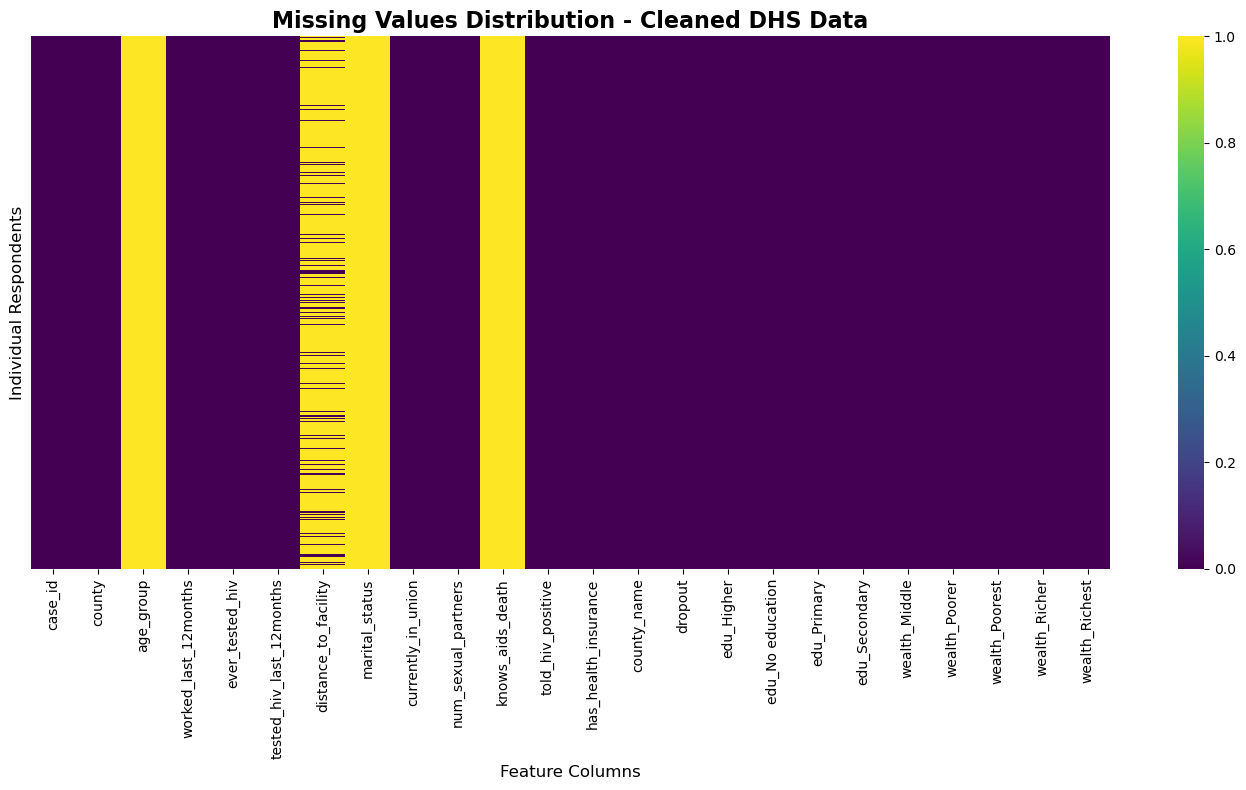


FINAL DATA QUALITY REPORT
Total missing values in cleaned dataset: 123991
⚠ WARNING: 123991 missing values remain


In [34]:
# Cell 12: Generate After-Cleaning Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(cleaner.clean_df.isnull(), yticklabels=False, cbar=True, cmap="viridis")
plt.title(
    "Missing Values Distribution - Cleaned DHS Data", fontsize=16, fontweight="bold"
)
plt.xlabel("Feature Columns", fontsize=12)
plt.ylabel("Individual Respondents", fontsize=12)
plt.tight_layout()

after_path = "../figures/dhs_missing_after.png"
plt.savefig(after_path, dpi=300, bbox_inches="tight")
plt.show()

total_missing = cleaner.clean_df.isnull().sum().sum()
print("\n" + "=" * 60)
print("FINAL DATA QUALITY REPORT")
print("=" * 60)
print(f"Total missing values in cleaned dataset: {total_missing}")

if total_missing == 0:
    print("✓ SUCCESS: Dataset is complete with no missing values")
    print("✓ Data ready for model training")
else:
    print(f"⚠ WARNING: {total_missing} missing values remain")

## Data Persistence

The cleaned dataset is exported to the processed data directory defined in constants.

In [35]:
# Cell 13: Save Cleaned Dataset
cleaner.save_clean_data(c.DHS_CLEAN)

if os.path.exists(c.DHS_CLEAN):
    file_size = os.path.getsize(c.DHS_CLEAN) / (1024 * 1024)
    print(f"File size: {file_size:.2f} MB")
    test_load = pd.read_csv(c.DHS_CLEAN)
    print(f"Verification: {test_load.shape[0]:,} rows, {test_load.shape[1]} columns")

Saved clean data to /home/skylar_lorena/DS/Phase5/Phase-5-HIV-Care-Gap-AI/data/processed/individual_features_clean.csv
File size: 4.09 MB
Verification: 32,156 rows, 24 columns


## Final Hand-off for Modeling

In [36]:
# Cell 14: Final Hand-off
ratios = cleaner.get_class_ratio()

if ratios:
    counts = cleaner.clean_df["dropout"].value_counts()
    neg_count = counts.get(0, 0)
    pos_count = counts.get(1, 0)
    total_count = len(cleaner.clean_df)
    dropout_rate = pos_count / total_count
    rec_weight = neg_count / pos_count if pos_count > 0 else 1.0

    print("=" * 60)
    print("FINAL HAND-OFF FOR MODELING")
    print("=" * 60)
    print(f"Cleaned Record Count: {total_count:,}")
    print(f"Identified Dropout Rate: {dropout_rate:.2%}")
    print(f"Recommended XGB_SCALE_POS_WEIGHT: {rec_weight:.2f}")
    print("-" * 60)
    print(
        "Task 03 successfully completed. Pipeline is reproducible via src/dhs_cleaner.py"
    )
    print("=" * 60)

print("\nClass Ratio for Modeling:")
print(cleaner.clean_df["dropout"].value_counts(normalize=True))

FINAL HAND-OFF FOR MODELING
Cleaned Record Count: 32,156
Identified Dropout Rate: 0.08%
Recommended XGB_SCALE_POS_WEIGHT: 1235.77
------------------------------------------------------------
Task 03 successfully completed. Pipeline is reproducible via src/dhs_cleaner.py

Class Ratio for Modeling:
dropout
0    0.999191
1    0.000809
Name: proportion, dtype: float64
